# Question 8  
In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

### (a)    
Create a random number generator and use its normal() method to generate a predictor $X$ of length $n = 100$, as well as a noise vector $\epsilon$ of length $n = 100$.

In [176]:
import numpy as np
n = 100
X = np.random.normal(0,1,n)
epsilon = np.random.normal(0,1,n) 

### (b)  
Generate a response vector $Y$ of length $n = 100$ according to the model$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon,$$where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.

In [177]:
# set beta randomly
beta0 = 3
beta1 = 0.5
beta2 = -2
beta3 = 1

Y = beta0 + beta1*X + beta2*(X**2) + beta3*(X**3) + epsilon

### (c)  
Use forward stepwise selection in order to select a model containing the predictors $X, X^2, \dots, X^{10}$. What is the model obtained according to $C_p$? $$C_p = \frac{RSS_d}{\hat{\sigma}^2} - n + 2d$$ Report the coefficients of the model obtained.

In [178]:
import pandas as pd

data = pd.DataFrame({'Y':Y})
for i in range(1,11):
    data[f'X{i}'] = X**i
predictors = [f'X{i}' for i in range(1,11)]
print(data.head(5))


          Y        X1        X2            X3            X4            X5  \
0  1.687352 -0.429583  0.184542 -7.927600e-02  3.405564e-02 -1.462973e-02   
1  1.979545 -0.005801  0.000034 -1.952379e-07  1.132624e-09 -6.570629e-12   
2  3.527072  0.361423  0.130626  4.721139e-02  1.706327e-02  6.167056e-03   
3  2.863647  0.741375  0.549636  4.074865e-01  3.021001e-01  2.239694e-01   
4  5.871963  0.164287  0.026990  4.434128e-03  7.284688e-04  1.196778e-04   

             X6            X7            X8            X9           X10  
0  6.284685e-03 -2.699795e-03  1.159786e-03 -4.982247e-04  2.140289e-04  
1  3.811785e-14 -2.211311e-16  1.282836e-18 -7.442050e-21  4.317317e-23  
2  2.228915e-03  8.055807e-04  2.911553e-04  1.052302e-04  3.803258e-05  
3  1.660452e-01  1.231017e-01  9.126449e-02  6.766118e-02  5.016228e-02  
4  1.966149e-05  3.230124e-06  5.306667e-07  8.718155e-08  1.432278e-08  


In [179]:
def nCp(sigma2, estimator, X, Y):
    n, p_plus_one = X.shape
    p = p_plus_one - 1
    
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)

    return -(RSS + 2 * p * sigma2) / n

In [180]:
import numpy as np
import pandas as pd
from statsmodels.api import OLS
from ISLP.models import ModelSpec as MS
from functools import partial
from ISLP.models import Stepwise

Y = data['Y']
design = MS(predictors).fit(data)

X_all = design.transform(data)

full_model_fit = OLS(Y, X_all).fit()
sigma2 = full_model_fit.scale
neg_Cp = partial(nCp, sigma2)

In [181]:
import numpy as np
import pandas as pd
from statsmodels.api import OLS
from functools import partial
from ISLP.models import ModelSpec as MS, \
                        Stepwise, \
                        sklearn_selected

strategy = Stepwise.first_peak(design,
                               max_terms=len(design.terms))

best_model = sklearn_selected(strategy, X_all, Y, scoring=neg_Cp)

In [182]:
selector = sklearn_selected(OLS,
                            strategy,
                            scoring=neg_Cp)
selector.fit(X_all, Y) 

print("Selected variables (Forward Cp selection):")
print(selector.selected_state_)

Selected variables (Forward Cp selection):
('X1', 'X2', 'X3')


### (d)  
Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?

In [183]:
from statsmodels.api import OLS, add_constant

def Cp(model, sigma2):
    RSS = np.sum(model.resid**2)
    p = len(model.params) - 1
    n = len(model.resid)
    return (RSS + 2*p*sigma2) / n

X_full = add_constant(data[predictors])
full_model = OLS(data['Y'], X_full).fit()
sigma2 = full_model.scale

current_predictors = predictors.copy()

while True:
    best_Cp = Cp(OLS(data['Y'], add_constant(data[current_predictors])).fit(), sigma2)
    worst_to_drop = None
    improved = False

    for var in current_predictors:
        trial = [v for v in current_predictors if v != var]
        model = OLS(data['Y'], add_constant(data[trial])).fit()
        cp_val = Cp(model, sigma2)
        
        if cp_val < best_Cp:
            best_Cp = cp_val
            worst_to_drop = var
            improved = True

    if improved:
        current_predictors.remove(worst_to_drop)
    else:
        break

print("Selected variables (Backward Cp selection):")
print(current_predictors)

Selected variables (Backward Cp selection):
['X1', 'X2', 'X3', 'X4', 'X6', 'X8', 'X10']


**comparison:**  
With the current beta settings, forward selection captures the true predictors, while backward selection keeps some non-informative variables.

### (e)  
Now fit a lasso model to the simulated data, again using $X, X^2, \dots, X^{10}$ as predictors. Use cross-validation to select the optimal value of $\lambda$. Create plots of the cross-validation error as a function of $\lambda$. Report the resulting coefficient estimates, and discuss the results obtained.

In [184]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[predictors])

lasso = LassoCV(cv=10, random_state=42)
lasso.fit(X_scaled, data['Y'])

coef = pd.Series(lasso.coef_, index=predictors)
selected = coef[coef != 0].index.tolist()

print("LASSO selected variables:")
print(selected)

#print("\nCoefficients:")
#print(coef)

LASSO selected variables:
['X1', 'X2', 'X3', 'X4']


=== Best lambda (alpha) ===
0.0622187700370972

=== Coefficients ===
X1     0.632157
X2    -2.807899
X3     3.376607
X4    -0.021012
X5     0.000000
X6    -0.000000
X7     0.000000
X8    -0.000000
X9     0.000000
X10   -0.000000
dtype: float64

=== Selected variables (non-zero) ===
['X1', 'X2', 'X3', 'X4']


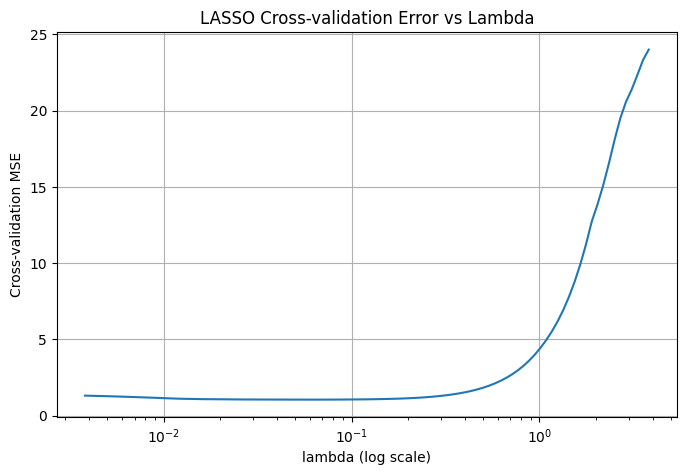

In [185]:
import matplotlib.pyplot as plt

coef = pd.Series(lasso.coef_, index=predictors)

print("=== Best lambda (alpha) ===")
print(lasso.alpha_)

print("\n=== Coefficients ===")
print(coef)

print("\n=== Selected variables (non-zero) ===")
print(coef[coef != 0].index.tolist())

plt.figure(figsize=(8,5))
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("Cross-validation MSE")
plt.title("LASSO Cross-validation Error vs Lambda")
plt.grid(True)
plt.show()

### (f)  
Now generate a response vector $Y$ according to the model$$Y = \beta_0 + \beta_7 X^7 + \epsilon,$$and perform forward stepwise selection and the lasso. Discuss the results obtained.

In [186]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

n = 100
X = np.random.normal(0,1,n)
epsilon = np.random.normal(0,1,n)

beta0 = -5
beta7 = 0.3

Y = beta0 + beta2*(X**7) + epsilon

data = pd.DataFrame({'Y':Y})
for i in range(1,11):
    data[f'X{i}'] = X**i

predictors = [f'X{i}' for i in range(1,11)]


In [187]:
# forward

def nCp(sigma2, estimator, X, Y):
    n, p_plus_one = X.shape
    p = p_plus_one - 1
    
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)

    return -(RSS + 2 * p * sigma2) / n

import numpy as np
import pandas as pd
from statsmodels.api import OLS
from ISLP.models import ModelSpec as MS
from functools import partial
from ISLP.models import Stepwise

Y = data['Y']
design = MS(predictors).fit(data)

X_all = design.transform(data)

full_model_fit = OLS(Y, X_all).fit()
sigma2 = full_model_fit.scale
neg_Cp = partial(nCp, sigma2)

import numpy as np
import pandas as pd
from statsmodels.api import OLS
from functools import partial
from ISLP.models import ModelSpec as MS, \
                        Stepwise, \
                        sklearn_selected

strategy = Stepwise.first_peak(design,
                               max_terms=len(design.terms))

best_model = sklearn_selected(strategy, X_all, Y, scoring=neg_Cp)

selector = sklearn_selected(OLS,
                            strategy,
                            scoring=neg_Cp)
selector.fit(X_all, Y) 

print("Selected variables (Forward Cp selection):")
print(selector.selected_state_)

Selected variables (Forward Cp selection):
('X7',)


In [188]:
# Lasso 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[predictors])

lasso = LassoCV(cv=10, random_state=42)
lasso.fit(X_scaled, data['Y'])

coef = pd.Series(lasso.coef_, index=predictors)
selected = coef[coef != 0].index.tolist()

print("LASSO selected variables:")
print(selected)

#print("\nCoefficients:")
#print(coef)

LASSO selected variables:
['X1', 'X2', 'X5', 'X7', 'X9']


**comparison:**  
With the current beta settings, forward selection still captures the true predictors, while lasso keeps some non-informative variables.